# DoS Attack Identifier

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## Data import / initial splitting

In [7]:
PATH = './DoS-Classifier/SUEE1.csv'
#PATH = '/home/tdokkad/Downloads/' + PATH

print("Loading SUEE1 dataset...")
df0 = pd.read_csv(PATH)
display(df0)

slowloris = np.asarray(["10.128.0." + str(i) for i in range(1, 50)])
slowhttptest = np.asarray(["10.128.0." + str(i) for i in range(51, 100)])
slowloris_ng = np.asarray(["10.128.0." + str(i) for i in range(101, 150)])

# if you need separate index arrays for each group:
slowloris_i = np.unique(np.hstack([
    np.where(df0["Source"].isin(slowloris)), 
    np.where(df0["Destination"].isin(slowloris))]))
slowhttptest_i = np.unique(np.hstack([
    np.where(df0["Source"].isin(slowhttptest)), 
    np.where(df0["Destination"].isin(slowhttptest))]))
slowloris_ng_i = np.unique(np.hstack([
    np.where(df0["Source"].isin(slowloris_ng)), 
    np.where(df0["Destination"].isin(slowloris_ng))]))

# for ip in df["Source"].values:
#     if ip in slowloris:
#         df["Label"] = "slowloris"
#     elif ip in slowhttptest:
#         df["Label"] = "slowhttptest"
#     elif ip in slowloris_ng:
#         df["Label"] = "slowloris_ng"
#     else:
#         df["Label"] = "normal"

# for ip in df["Destination"].values:
#     if ip in slowloris:
#         df["Label"] = "slowloris"
#     elif ip in slowhttptest:
#         df["Label"] = "slowhttptest"
#     elif ip in slowloris_ng:
#         df["Label"] = "slowloris_ng"
#     else:
#         df["Label"] = "normal"

# Split samples into training and test sets
# feat_train, feat_test, y_train, y_test = train_test_split(
#     feat_all, y_all, test_size=0.4, random_state=0
# )


print(slowloris_i.shape)
print(slowhttptest_i.shape)
print(slowloris_ng_i.shape)
print("Completed.")

Loading SUEE1 dataset...


,No.,Time,Source,Destination,Protocol,Length,Info
0,1,0.000000,192.168.0.1,192.168.0.2,TCP,66,"80 > 39266 [FIN, ACK] Seq=1 Ack=1 Win=235 Le..."
1,2,0.038679,192.168.0.2,192.168.0.1,TCP,66,39266 > 80 [ACK] Seq=1 Ack=2 Win=245 Len=0 T...
2,3,0.156902,192.168.0.1,192.168.0.3,TCP,54,"80 > 9784 [FIN, ACK] Seq=1 Ack=1 Win=237 Len=0"
3,4,0.158266,192.168.0.3,192.168.0.1,TCP,54,9784 > 80 [ACK] Seq=1 Ack=2 Win=254 Len=0
4,5,0.593252,192.168.0.1,192.168.0.4,TCP,66,"80 > 62170 [FIN, ACK] Seq=1 Ack=1 Win=235 Le..."
...,...,...,...,...,...,...,...
2089431,2089432,464.968751,192.168.0.8,192.168.0.1,TCP,66,[TCP ACKed unseen segment] [TCP Previous segme...
2089432,2089433,465.155756,192.168.0.15,192.168.0.1,TCP,54,[TCP ACKed unseen segment] [TCP Previous segme...
2089433,2089434,465.888553,192.168.0.1,192.168.6.139,TCP,66,"80 > 42640 [PSH, ACK] Seq=1 Ack=468 Win=3008..."
2089434,2089435,466.022984,192.168.0.7,192.168.0.1,TCP,74,[TCP Port numbers reused] 48110 > 80 [SYN] S...


(2204,)
(6586,)
(17702,)
Completed.


In [8]:
df = df0.copy()
# Remove provided numbering; just use pandas automatic zero-indexing
df.drop(['No.'], axis=1, inplace=True)

HOST_ADDRESS = '192.168.0.1'

# Convert the IP arrays defined above to sets for O(1) lookup
slowloris_set    = set(slowloris)     # 10.128.0.1  - 10.128.0.49
slowhttptest_set = set(slowhttptest)  # 10.128.0.51 - 10.128.0.99
slowloris_ng_set = set(slowloris_ng)  # 10.128.0.101 - 10.128.0.149
# .50 and .100 each appear in two groups (off-by-one in capture) -- omit entirely
ambiguous_ips    = {'10.128.0.50', '10.128.0.100'}

# Inbound / Outbound relative to the monitored server
df['Inbound']  = (df['Destination'] == HOST_ADDRESS)
df['Outbound'] = (df['Source']      == HOST_ADDRESS)

# 4-class label:  0 = benign
#                 1 = slowloris
#                 2 = slowhttptest
#                 3 = slowloris-ng
#                -1 = ambiguous (will be dropped)
def assign_label(src, dst):
    both = {src, dst}
    if both & ambiguous_ips:       return -1
    if both & slowloris_set:       return 1
    if both & slowhttptest_set:    return 2
    if both & slowloris_ng_set:    return 3
    return 0

df['Label'] = [assign_label(s, d) for s, d in zip(df['Source'], df['Destination'])]

# Drop ambiguous-IP rows, then drop IP columns
df = df[df['Label'] != -1].reset_index(drop=True)
df.drop(['Source', 'Destination'], axis=1, inplace=True)

label_names = {0: 'benign', 1: 'slowloris', 2: 'slowhttptest', 3: 'slowloris-ng'}
total = len(df)
print(f"Rows after dropping ambiguous IPs: {total:,}")
for k, name in label_names.items():
    n = (df['Label'] == k).sum()
    print(f"  {k}  {name:<14}: {n:>8,}  ({100*n/total:.3f}%)")
display(df)


Rows after dropping ambiguous IPs: 2,088,765
  0  benign        : 2,062,273  (98.732%)
  1  slowloris     :    2,204  (0.106%)
  2  slowhttptest  :    6,586  (0.315%)
  3  slowloris-ng  :   17,702  (0.847%)


,Time,Protocol,Length,Info,Inbound,Outbound,Label
0,0.000000,TCP,66,"80 > 39266 [FIN, ACK] Seq=1 Ack=1 Win=235 Le...",False,True,0
1,0.038679,TCP,66,39266 > 80 [ACK] Seq=1 Ack=2 Win=245 Len=0 T...,True,False,0
2,0.156902,TCP,54,"80 > 9784 [FIN, ACK] Seq=1 Ack=1 Win=237 Len=0",False,True,0
3,0.158266,TCP,54,9784 > 80 [ACK] Seq=1 Ack=2 Win=254 Len=0,True,False,0
4,0.593252,TCP,66,"80 > 62170 [FIN, ACK] Seq=1 Ack=1 Win=235 Le...",False,True,0
...,...,...,...,...,...,...,...
2088760,464.968751,TCP,66,[TCP ACKed unseen segment] [TCP Previous segme...,True,False,0
2088761,465.155756,TCP,54,[TCP ACKed unseen segment] [TCP Previous segme...,True,False,0
2088762,465.888553,TCP,66,"80 > 42640 [PSH, ACK] Seq=1 Ack=468 Win=3008...",False,True,0
2088763,466.022984,TCP,74,[TCP Port numbers reused] 48110 > 80 [SYN] S...,True,False,0


In [9]:
# Split X by protocol
tcp_indices = df['Protocol'] == 'TCP'
df_marked_tcp = df[tcp_indices].copy()
# y_tcp = y[tcp_indices]

http_indices = df['Protocol'] == 'HTTP'
df_marked_http = df[http_indices].copy()
# y_http = y[http_indices]

print(f'{len(tcp_indices)} items use TCP; malicious proportion: {sum(df_marked_tcp['Label'].to_numpy()) / len(df_marked_tcp)}')
print(f'{len(http_indices)} items use HTTP; malicious proportion: {sum(df_marked_http['Label'].to_numpy()) / len(df_marked_http)}')

2088765 items use TCP; malicious proportion: 0.03230451482650809
2088765 items use HTTP; malicious proportion: 1.99609375


This is notable -- *none* of the traffic captured as HTTP is from benign addresses.

Since the information present in the dataset depends significantly on what protocol is used (many features can be extracted from the 'info' field, which is completely different depending on protocol), we can much more effectively analyze by splitting by protocol. Since only malicious HTTP traffic is recorded, the best analysis that any model can give of HTTP traffic is to mark it all as malicious.

It becomes apparent during further processing that some of the rows Wireshark categorizes as TCP 

In [10]:
# Preview a random-ish set of 'info' content for each category
print('TCP:')
info = df_marked_tcp['Info'].to_numpy()
for rand_index in np.random.randint(0, len(info), 15):
    print(info[rand_index])
display(df_marked_tcp)

print('HTTP:')
info = df_marked_http['Info'].to_numpy()
for rand_index in np.random.randint(0, len(info), 15):
    print(info[rand_index])
display(df_marked_http)

TCP:
57105  >  80 [FIN, ACK] Seq=113 Ack=1224 Win=64256 Len=0
[TCP ACKed unseen segment] [TCP Previous segment not captured] 80  >  53764 [PSH, ACK] Seq=1414 Ack=693 Win=31104 Len=0 TSval=477321452 TSecr=188764156
[TCP ACKed unseen segment] 4080  >  443 [ACK] Seq=977 Ack=596925 Win=66560 Len=0
45804  >  443 [SYN] Seq=0 Win=29200 Len=0 MSS=1460 SACK_PERM TSval=479488628 TSecr=0 WS=128
80  >  56860 [SYN, ACK] Seq=0 Ack=1 Win=64074 Len=0 SACK_PERM TSval=34031091 TSecr=495117933 MSS=1460 WS=4
[TCP Dup ACK 1993604#1] 55713  >  80 [PSH, ACK] Seq=1 Ack=1 Win=14656 Len=0 TSval=377158 TSecr=497628279
[TCP ACKed unseen segment] [TCP Previous segment not captured] 42766  >  443 [PSH, ACK] Seq=1147 Ack=4916 Win=39040 Len=0 TSval=481499224 TSecr=225518325
80  >  56821 [ACK] Seq=1216 Ack=114 Win=29312 Len=0
[TCP Dup ACK 758971#1] 59786  >  80 [PSH, ACK] Seq=2798 Ack=71703 Win=65536 Len=0
50935  >  80 [ACK] Seq=1 Ack=1 Win=65536 Len=0
443  >  38814 [SYN, ACK] Seq=0 Ack=1 Win=28960 Len=0 MSS=1460 SACK

,Time,Protocol,Length,Info,Inbound,Outbound,Label
0,0.000000,TCP,66,"80 > 39266 [FIN, ACK] Seq=1 Ack=1 Win=235 Le...",False,True,0
1,0.038679,TCP,66,39266 > 80 [ACK] Seq=1 Ack=2 Win=245 Len=0 T...,True,False,0
2,0.156902,TCP,54,"80 > 9784 [FIN, ACK] Seq=1 Ack=1 Win=237 Len=0",False,True,0
3,0.158266,TCP,54,9784 > 80 [ACK] Seq=1 Ack=2 Win=254 Len=0,True,False,0
4,0.593252,TCP,66,"80 > 62170 [FIN, ACK] Seq=1 Ack=1 Win=235 Le...",False,True,0
...,...,...,...,...,...,...,...
2088760,464.968751,TCP,66,[TCP ACKed unseen segment] [TCP Previous segme...,True,False,0
2088761,465.155756,TCP,54,[TCP ACKed unseen segment] [TCP Previous segme...,True,False,0
2088762,465.888553,TCP,66,"80 > 42640 [PSH, ACK] Seq=1 Ack=468 Win=3008...",False,True,0
2088763,466.022984,TCP,74,[TCP Port numbers reused] 48110 > 80 [SYN] S...,True,False,0


HTTP:
GET /bcrypt.php HTTP/1.1 
GET /bcrypt.php HTTP/1.1 
GET /bcrypt.php HTTP/1.1 
[TCP Retransmission] GET /bcrypt.php HTTP/1.1 
[TCP Retransmission] GET /bcrypt.php HTTP/1.1 
HTTP/1.1 400 Bad Request  (text/html)
HTTP/1.1 400 Bad Request  (text/html)
GET /bcrypt.php HTTP/1.1 
[TCP Retransmission] GET /bcrypt.php HTTP/1.1 
GET /bcrypt.php HTTP/1.1 
GET /bcrypt.php HTTP/1.1 
GET /bcrypt.php HTTP/1.1 
[TCP Retransmission] GET /bcrypt.php HTTP/1.1 
GET /bcrypt.php HTTP/1.1 
GET /bcrypt.php HTTP/1.1 


,Time,Protocol,Length,Info,Inbound,Outbound,Label
98979,413.596335,HTTP,254,GET /bcrypt.php HTTP/1.1,False,False,2
98995,413.599208,HTTP,254,GET /bcrypt.php HTTP/1.1,False,False,2
99013,413.600983,HTTP,254,GET /bcrypt.php HTTP/1.1,False,False,2
99020,413.601070,HTTP,254,GET /bcrypt.php HTTP/1.1,False,False,2
99026,413.601113,HTTP,254,GET /bcrypt.php HTTP/1.1,False,False,2
...,...,...,...,...,...,...,...
125768,-3623.088889,HTTP,254,[TCP Retransmission] GET /bcrypt.php HTTP/1.1,False,False,2
125773,-3621.040843,HTTP,254,[TCP Retransmission] GET /bcrypt.php HTTP/1.1,False,False,2
125774,-3621.040824,HTTP,254,[TCP Retransmission] GET /bcrypt.php HTTP/1.1,False,False,2
125779,-3617.840848,HTTP,254,[TCP Retransmission] GET /bcrypt.php HTTP/1.1,False,False,2


In [11]:
# Break down 'info' field into structured format

# Extract bracketed arguments from start of string
def extract_front_bracketed(str):
    pre_args = []
    while str[0] == '[':
        pre_arg, str = str[1:].split(']', 1)
        pre_args.append(pre_arg)
        str = str.lstrip()
    
    return pre_args, str

# Extract bracketed arguments from end of string
def extract_hind_bracketed(str):
    post_args = []
    while str[-1] == ']':
        str, post_arg = str[:-1].split('[', 1)
        post_args.append(post_arg)
        str = str.rstrip()
    
    return post_args[::-1], str

# Process 'Info' field of converted PCAP CSV
def process_info_tcp(info):
    copy = info

    # Additional logic for handling http-via-tcp:
    if '  >  ' not in info:
        # print(info)
        return None

    pre_args, info = extract_front_bracketed(info)
    
    # Source and destination port numbers (TODO: make sure these are being interpreted correctly)
    if len(info.split('  >  ', 1)) < 2:
        print(copy)
    source_port, info = info.split('  >  ', 1)
    dest_port, info = info.split(' ', 1)
    source_port = int(source_port)
    dest_port = int(dest_port)

    # Middle bracketed arguments
    mid_args, info = extract_front_bracketed(info)
    if len(mid_args) > 0:
        assert(len(mid_args) == 1)
        mid_args = mid_args[0].split(', ')

    # End bracketed arguments
    post_args, info = extract_hind_bracketed(info)

    vars = {}
    for var in info.split(' '):
        if '=' in var:
            k, v = var.split('=')
        else:
            k, v = var, 0
        vars[k] = int(v)

    return [pre_args, source_port, dest_port, mid_args, vars, post_args]


We had to modify this code because some of the packets labeled as TCP still format their 'info' fields like the HTTP messages. Next we try looking at all of these messages.

In [12]:
from tqdm import tqdm

http_rows_in_Xtcp = []
# decomposed_info_arr = []    # Building nested list, then converting to DF is much faster than appending to DF directly
decomposed_info_arr = []
mislabeled = []

info = df_marked_tcp['Info'].to_numpy()
for i in tqdm(range(len(df_marked_tcp)), 'Processing info fields'):
    info_components = process_info_tcp(info[i])
    # Set aside elements that do not match expected TCP formats
    # if (info_components == None):
    #     http_rows_in_Xtcp.append(i)
    #     continue

    # decomposed_info_arr.append([i] + info_components)
    mislabeled.append(info_components == None)

    if info_components != None:
        decomposed_info_arr.append(info_components)

# df_tcp['Info components'] = decomposed_info

decomposed_info = pd.DataFrame(
    decomposed_info_arr,
    columns=['Pre-brackets', 'Source port', 'Dest port', 'Mid-brackets', 'Vars', 'Post-brackets']
)

Processing info fields:   0%|          | 0/2088253 [00:00<?, ?it/s]

Processing info fields: 100%|██████████| 2088253/2088253 [00:24<00:00, 85209.28it/s] 


In [13]:
# mislabeled_indices = np.where(df_tcp['Info components'] == None)
df_marked_tcp['Mislabeled'] = mislabeled

df_mislabeled = df_marked_tcp.loc[df_marked_tcp['Mislabeled']]
display(df_mislabeled)

# X_mislabeled = df_tcp.loc[http_rows_in_Xtcp] # Offset is required to target the right values
# display(X_mislabeled)

# y_mislabeled = y_tcp[http_rows_in_Xtcp]

# print(f'{len(http_rows_in_Xtcp)} items are labeled TCP but have HTTP-style \'Info\' fields; \
# malicious proportion: {sum(y_mislabeled) / len(y_mislabeled)}')

,Time,Protocol,Length,Info,Inbound,Outbound,Label,Mislabeled
100134,413.852056,TCP,164,HTTP/1.1 200 OK [TCP PDU reassembled in 100164],False,False,2,True
100535,414.969776,TCP,164,HTTP/1.1 200 OK [TCP PDU reassembled in 100567],False,False,2,True
100561,415.975408,TCP,164,HTTP/1.1 200 OK [TCP PDU reassembled in 100593],False,False,2,True
100563,415.976600,TCP,164,HTTP/1.1 200 OK [TCP PDU reassembled in 100598],False,False,2,True
100924,416.987761,TCP,164,HTTP/1.1 200 OK [TCP PDU reassembled in 100968],False,False,2,True
...,...,...,...,...,...,...,...,...
124615,-3642.151076,TCP,55,GET /?294 HTTP/1.1 [TCP PDU reassembled in 12...,False,False,3,True
124637,-3641.850490,TCP,55,GET /?1593 HTTP/1.1 [TCP PDU reassembled in 1...,False,False,3,True
124659,-3641.702004,TCP,55,GET /?140 HTTP/1.1 [TCP PDU reassembled in 12...,False,False,3,True
124679,-3641.616037,TCP,55,GET /?1807 HTTP/1.1 [TCP PDU reassembled in 1...,False,False,3,True


<p>Like the items that Wireshark does label as HTTP, none of these are from benign traffic.</p>

<p>We will move them to the HTTP dataset, so that we can make use of more features from the genuine TCP datasets. If we had any benign data in the HTTP group, we could train a seperate classifier but in the current state we cannot improve on simply marking all such traffic as malicious.</p>

In [14]:
df_tcp = df_marked_tcp.loc[np.logical_not(df_marked_tcp['Mislabeled'])].reset_index()
print(len(df_marked_tcp), len(df_marked_http), len(df_mislabeled))

# TODO: Convert this back to dataframe (and reset index). It is currently a numpy array
df_http = np.concatenate([df_marked_http, df_mislabeled.drop(['Mislabeled'], axis=1)]) 
print(len(df_tcp), len(df_http))

# print(np.where(mislabeled)[0])

# df2_tcp = df_marked_tcp.drop(np.where(mislabeled)[0], axis=0)
# print(len(df2_tcp), len(df2_http))

# df_http = pd.concat([df_http, X_mislabeled])
# y_http = np.concatenate([y_http, y_mislabeled])

# # In X_tcp need to convert row numbers to indices for drop()
# df_tcp.drop([df_tcp.iloc[i, 0] for i in http_rows_in_Xtcp], inplace=True)
# y_tcp = np.delete(y_tcp, http_rows_in_Xtcp)

2088253 512 122
2088131 634


In [15]:
# Combine the new info-field features into X_tcp
# To avoid dealing with indexing we manually move column by column
# (Ordering should not have been perturbed during previous operations)
# For safety check that columns are the same size first
assert(len(df_tcp) == len(decomposed_info)) 
for col in decomposed_info.columns:
    df_tcp[col] = decomposed_info[col]

display(df_tcp)

,index,Time,Protocol,Length,Info,Inbound,Outbound,Label,Mislabeled,Pre-brackets,Source port,Dest port,Mid-brackets,Vars,Post-brackets
0,0,0.000000,TCP,66,"80 > 39266 [FIN, ACK] Seq=1 Ack=1 Win=235 Le...",False,True,0,False,[],80,39266,"[FIN, ACK]","{'Seq': 1, 'Ack': 1, 'Win': 235, 'Len': 0, 'TS...",[]
1,1,0.038679,TCP,66,39266 > 80 [ACK] Seq=1 Ack=2 Win=245 Len=0 T...,True,False,0,False,[],39266,80,[ACK],"{'Seq': 1, 'Ack': 2, 'Win': 245, 'Len': 0, 'TS...",[]
2,2,0.156902,TCP,54,"80 > 9784 [FIN, ACK] Seq=1 Ack=1 Win=237 Len=0",False,True,0,False,[],80,9784,"[FIN, ACK]","{'Seq': 1, 'Ack': 1, 'Win': 237, 'Len': 0}",[]
3,3,0.158266,TCP,54,9784 > 80 [ACK] Seq=1 Ack=2 Win=254 Len=0,True,False,0,False,[],9784,80,[ACK],"{'Seq': 1, 'Ack': 2, 'Win': 254, 'Len': 0}",[]
4,4,0.593252,TCP,66,"80 > 62170 [FIN, ACK] Seq=1 Ack=1 Win=235 Le...",False,True,0,False,[],80,62170,"[FIN, ACK]","{'Seq': 1, 'Ack': 1, 'Win': 235, 'Len': 0, 'TS...",[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2088126,2088760,464.968751,TCP,66,[TCP ACKed unseen segment] [TCP Previous segme...,True,False,0,False,"[TCP ACKed unseen segment, TCP Previous segmen...",53188,80,[ACK],"{'Seq': 693, 'Ack': 2823, 'Win': 34944, 'Len':...",[]
2088127,2088761,465.155756,TCP,54,[TCP ACKed unseen segment] [TCP Previous segme...,True,False,0,False,"[TCP ACKed unseen segment, TCP Previous segmen...",51879,80,[ACK],"{'Seq': 113, 'Ack': 1203, 'Win': 64256, 'Len': 0}",[]
2088128,2088762,465.888553,TCP,66,"80 > 42640 [PSH, ACK] Seq=1 Ack=468 Win=3008...",False,True,0,False,[],80,42640,"[PSH, ACK]","{'Seq': 1, 'Ack': 468, 'Win': 30080, 'Len': 0,...",[]
2088129,2088763,466.022984,TCP,74,[TCP Port numbers reused] 48110 > 80 [SYN] S...,True,False,0,False,[TCP Port numbers reused],48110,80,[SYN],"{'Seq': 0, 'Win': 29200, 'Len': 0, 'MSS': 1460...",[]


We can now start exploring the info field contents in depth.

## Exploring the TCP info field

In [16]:
display(decomposed_info)
display()

,Pre-brackets,Source port,Dest port,Mid-brackets,Vars,Post-brackets
0,[],80,39266,"[FIN, ACK]","{'Seq': 1, 'Ack': 1, 'Win': 235, 'Len': 0, 'TS...",[]
1,[],39266,80,[ACK],"{'Seq': 1, 'Ack': 2, 'Win': 245, 'Len': 0, 'TS...",[]
2,[],80,9784,"[FIN, ACK]","{'Seq': 1, 'Ack': 1, 'Win': 237, 'Len': 0}",[]
3,[],9784,80,[ACK],"{'Seq': 1, 'Ack': 2, 'Win': 254, 'Len': 0}",[]
4,[],80,62170,"[FIN, ACK]","{'Seq': 1, 'Ack': 1, 'Win': 235, 'Len': 0, 'TS...",[]
...,...,...,...,...,...,...
2088126,"[TCP ACKed unseen segment, TCP Previous segmen...",53188,80,[ACK],"{'Seq': 693, 'Ack': 2823, 'Win': 34944, 'Len':...",[]
2088127,"[TCP ACKed unseen segment, TCP Previous segmen...",51879,80,[ACK],"{'Seq': 113, 'Ack': 1203, 'Win': 64256, 'Len': 0}",[]
2088128,[],80,42640,"[PSH, ACK]","{'Seq': 1, 'Ack': 468, 'Win': 30080, 'Len': 0,...",[]
2088129,[TCP Port numbers reused],48110,80,[SYN],"{'Seq': 0, 'Win': 29200, 'Len': 0, 'MSS': 1460...",[]


### Source and destination ports

These are the simplest values here; there is always one value present for each packet.

Source port contains 2088131 items, 36042 unique


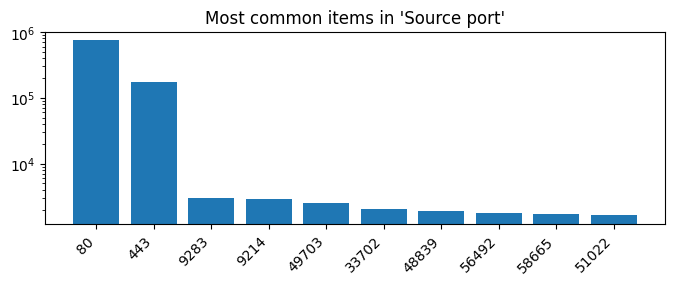

Dest port contains 2088131 items, 36005 unique


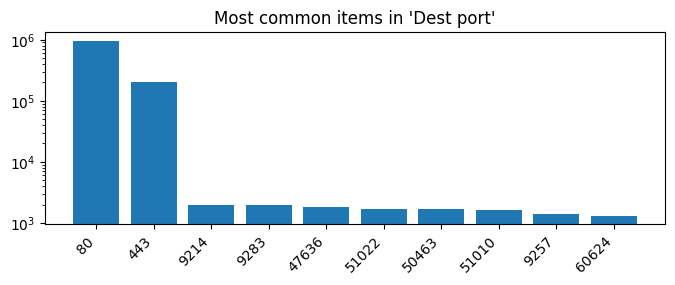

In [17]:
from collections import Counter

def summarize(items, name, log_scale=True):
    counter = Counter(items)
    most_common = counter.most_common(10)
    freqs = [f for (x, f) in most_common]
    most_common = [str(x) for (x, f) in most_common]

    print(f'{name} contains {len(items)} items, {len(np.unique(items))} unique')

    # Plot most commmon ports
    fig = plt.figure(figsize=(8, 2.5))
    plt.bar(x=most_common, height=freqs, log=log_scale)

    ax = fig.axes[0]

    plt.title(f'Most common items in \'{name}\'')
    plt.setp( ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    plt.show()

source_ports = df_tcp['Source port'].to_numpy()
dest_ports = df_tcp['Dest port'].to_numpy()

summarize(source_ports, 'Source port', True)
summarize(dest_ports, 'Dest port', True)

These are similar in distribution. The most common values by far are 80 (the default port for HTTP) and 443 (the default port for HTTPS)

In [18]:
http = np.logical_or(source_ports==80, dest_ports==80)      # Using HTTP port either in source or dest
https = np.logical_or(source_ports==443, dest_ports==443)   # Using HTTPS port either in source or dest
httpx = np.logical_or(http, https)

count_httpx = sum(httpx)
count_total = len(httpx)
print(f'{count_httpx} using HTTP or HTTPS, out of {count_total} total ({count_httpx/count_total})')

# If this fails, check that new columns merged correctly
assert(count_httpx == count_total)

2088131 using HTTP or HTTPS, out of 2088131 total (1.0)


In [19]:
count_both = np.sum(np.logical_and(http, https))
print(f'{count_both} using both HTTP and HTTPS, out of {count_total} total ({count_both/count_total})')

0 using both HTTP and HTTPS, out of 2088131 total (0.0)


Almost all traffic uses either the HTTP port or the HTTPS port (and never both).

### Prefixed tags

Wireshark sometimes adds tags at the beginning of the info field. These generally seem to indicate the relationship this packet has to previous ones. Since we are using individual packets as datapoints for training, this information may be very useful.

In [20]:
pre_brackets = df_tcp['Pre-brackets'].to_numpy()

all_tags = []
for l in pre_brackets:
    all_tags += l
unique_tags = np.unique(all_tags)

print(f'{len(all_tags)} tags, {len(unique_tags)} unique')

for i in range(10):
    print(unique_tags[i]) 

1774671 tags, 256150 unique
TCP ACKed unseen segment
TCP Dup ACK 10000#1
TCP Dup ACK 1000047#1
TCP Dup ACK 1000053#1
TCP Dup ACK 1000055#1
TCP Dup ACK 1000067#1
TCP Dup ACK 1000069#1
TCP Dup ACK 1000072#1
TCP Dup ACK 1000074#1
TCP Dup ACK 1000096#1


There are a lot of values of the form <code>TCP Dup ACK [number]#1</code>

Dup ACK Num1 contains 256140 items, 244118 unique


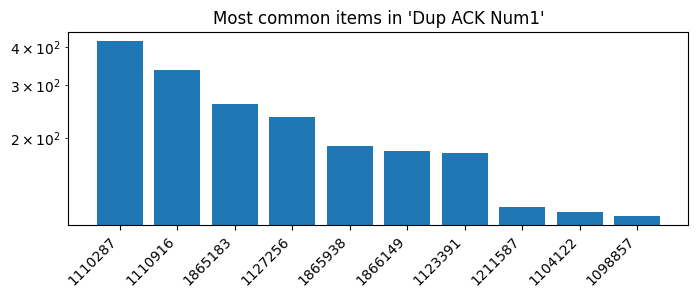

Dup ACK Num2 contains 256140 items, 418 unique


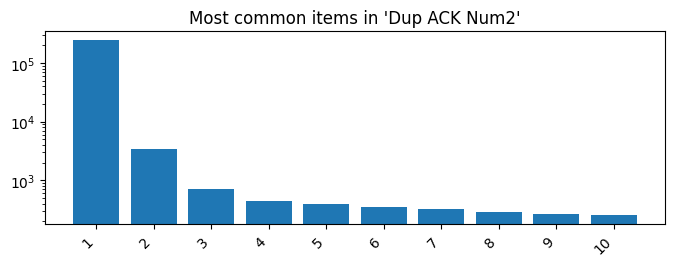

Other Tags contains 1518531 items, 10 unique


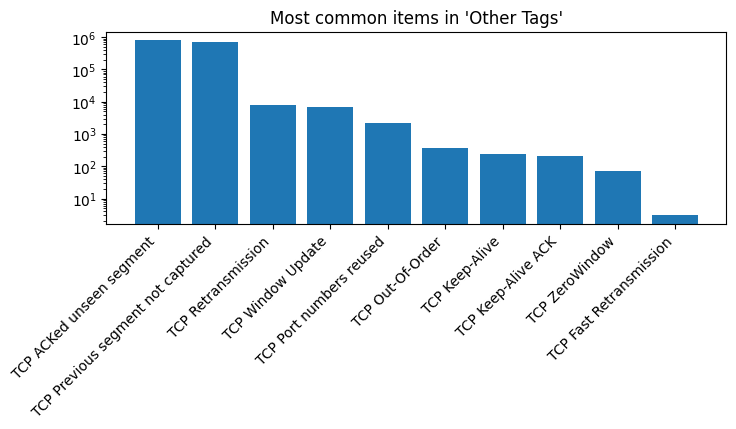

In [21]:
num1 = []
num2 = []

other_tags = []

for tag in all_tags:
    if not tag.startswith('TCP Dup ACK'):
        other_tags.append(tag)
        continue

    n1, n2 = tag.lstrip('TCP Dup ACK').rstrip().split('#')
    num1.append(n1)
    num2.append(n2)

summarize(num1, 'Dup ACK Num1', True)
summarize(num2, 'Dup ACK Num2', True)

summarize(other_tags, 'Other Tags', log_scale=True)

It appears that the first number (before the `#`) is an identifier of which packet was duplicated, while the second marks how many times the message has been retransmitted so far. The packet identifier seems unlikely to generalize well, but the duplicate number is probably usable as a feature. We can say that any packet without this tag has a duplicate number of zero. Due to its highly right-skewed shape, we will probably want to transform it (perhaps to `log(x+1)`).

Aside from the duplicate count, there are ten other tags. Most of these have at least 100 occurrences, but TCP Fast Retransmission occurs less than 10 times. In order to condense, we can probably merge it with TCP Retransmission. In general, we can set these as binary features (either a packet has each tag or it doesn't). These features are fairly sparse; there are less total tag occurrences than packets.

### Infixed tags

There is another set of tags after the source and destination ports. There is usually (or always?) at least one tag here, and often multiple. 

Tags contains 2770809 items, 7 unique


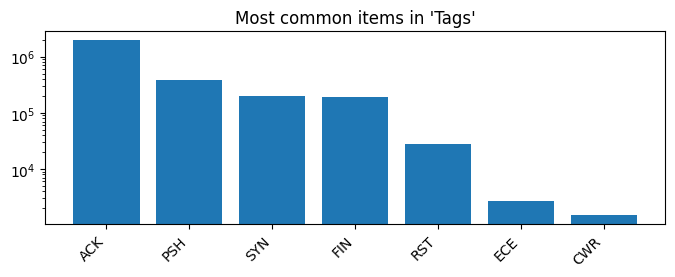

In [22]:
mid_brackets = df_tcp['Mid-brackets'].to_numpy()

tags = []
for l in mid_brackets:
    tags += l

summarize(tags, 'Tags', True)

Here there are only seven values possible. All have >1000 occurrences, so it is probably reasonable to include them as features.

### Postfixed tags

In [23]:
post_brackets = df_tcp['Post-brackets'].to_numpy()

tags = []

for l in post_brackets:
    tags += l

for tag in tags[0:5]:
    print(tag)

tags_atypical_format = []
for tag in tags:
    if not tag.startswith('TCP PDU reassembled in'):
        tags_atypical_format.append(tag)

print(f'{len(tags_atypical_format)} of {len(tags)} tags deviate from pattern \'TCP PDU reassembled in...\'')

TCP PDU reassembled in 100164
TCP PDU reassembled in 100323
TCP PDU reassembled in 100334
TCP PDU reassembled in 100223
TCP PDU reassembled in 100327
0 of 9628 tags deviate from pattern 'TCP PDU reassembled in...'


All of the suffixed tags follow the same format, with no unique information except these ID markers. Similar to the prefixed tags, we expect that the ID markers will not be useful, but we can create one binary feature marking the presence of this tag.

### TCP Feature Matrix

We now convert all parsed `Info` components into usable numeric/binary columns and assemble the final TCP feature matrix. IP addresses are excluded. The `Label` column becomes `y_tcp`.

In [24]:
# TCP: Assemble feature matrix
# Expected columns on df_tcp:
#   Time, Length, Inbound, Outbound, Label
#   Source port, Dest port
#   Pre-brackets  (list of prefixed anomaly tags)
#   Mid-brackets  (list of TCP flag tokens, e.g. ['FIN','ACK'])
#   Vars          (dict: Seq, Ack, Win, Len, TSval, TSecr)
#   Post-brackets (list - presence signals PDU reassembly)

import pandas as pd
import numpy as np

# Labels (0=benign, 1=slowloris, 2=slowhttptest, 3=slowloris-ng)
y_tcp = df_tcp['Label'].to_numpy()

# Base numeric features
feat_tcp = pd.DataFrame()
feat_tcp['Time']    = df_tcp['Time']
feat_tcp['Length']  = df_tcp['Length']
feat_tcp['Inbound'] = df_tcp['Inbound'].astype(int)
feat_tcp['Outbound']= df_tcp['Outbound'].astype(int)

# Port number features
feat_tcp['Source_port'] = pd.to_numeric(df_tcp['Source port'], errors='coerce').fillna(0).astype(int)
feat_tcp['Dest_port']   = pd.to_numeric(df_tcp['Dest port'],   errors='coerce').fillna(0).astype(int)
# Flag whether server port (80 or 443) is on source or destination side
feat_tcp['Server_is_src']  = (feat_tcp['Source_port'] == 80) | (feat_tcp['Source_port'] == 443)
feat_tcp['Server_is_dest'] = (feat_tcp['Dest_port']   == 80) | (feat_tcp['Dest_port']   == 443)

# Mid-bracket TCP flags (binary one-hot)
TCP_FLAGS = ['SYN', 'ACK', 'FIN', 'PSH', 'RST', 'URG', 'ECE']
mid = df_tcp['Mid-brackets'].to_numpy()
for flag in TCP_FLAGS:
    feat_tcp[f'flag_{flag}'] = [int(flag in tags) for tags in mid]

# Pre-bracket anomaly tags (keep only those with >=100 occurrences)
pre = df_tcp['Pre-brackets'].to_numpy()
pre_tag_counts = {}
for tags in pre:
    for t in tags:
        pre_tag_counts[t] = pre_tag_counts.get(t, 0) + 1
pre_tag_vocab = [t for t, c in pre_tag_counts.items() if c >= 100]
print(f"Pre-bracket tags kept (>=100 occurrences): {pre_tag_vocab}")
for tag in pre_tag_vocab:
    col = 'pre_' + tag.replace(' ', '_')
    feat_tcp[col] = [int(tag in tags) for tags in pre]

# Post-bracket: binary flag for PDU reassembly
post = df_tcp['Post-brackets'].to_numpy()
feat_tcp['has_pdu_reassembly'] = [int(len(tags) > 0) for tags in post]

# Numeric vars from Info dict: Seq, Ack, Win, Len, TSval, TSecr
VAR_KEYS = ['Seq', 'Ack', 'Win', 'Len', 'TSval', 'TSecr']
vars_col = df_tcp['Vars'].to_numpy()
for key in VAR_KEYS:
    feat_tcp[f'var_{key}'] = [
        float(d[key]) if isinstance(d, dict) and key in d else np.nan
        for d in vars_col
    ]
    med = feat_tcp[f'var_{key}'].median()
    feat_tcp[f'var_{key}'] = feat_tcp[f'var_{key}'].fillna(med)

print(f"TCP feature matrix shape: {feat_tcp.shape}")
print("TCP label distribution:")
for k, name in label_names.items():
    n = int((y_tcp == k).sum())
    print(f"  {k}  {name:<14}: {n:>8,}  ({100*n/len(y_tcp):.3f}%)")
feat_tcp.head(3)


Pre-bracket tags kept (>=100 occurrences): ['TCP ACKed unseen segment', 'TCP Previous segment not captured', 'TCP Retransmission', 'TCP Port numbers reused', 'TCP Keep-Alive', 'TCP Keep-Alive ACK', 'TCP Out-Of-Order', 'TCP Window Update']
TCP feature matrix shape: (2088131, 30)
TCP label distribution:
  0  benign        : 2,062,271  (98.762%)
  1  slowloris     :    2,106  (0.101%)
  2  slowhttptest  :    6,150  (0.295%)
  3  slowloris-ng  :   17,604  (0.843%)


,Time,Length,Inbound,Outbound,Source_port,Dest_port,Server_is_src,Server_is_dest,flag_SYN,flag_ACK,...,pre_TCP_Keep-Alive_ACK,pre_TCP_Out-Of-Order,pre_TCP_Window_Update,has_pdu_reassembly,var_Seq,var_Ack,var_Win,var_Len,var_TSval,var_TSecr
0,0.000000,66,0,1,80,39266,True,False,0,1,...,0,0,0,0,1.0,1.0,235.0,0.0,476819247.0,19947819.0
1,0.038679,66,1,0,39266,80,False,True,0,1,...,0,0,0,0,1.0,2.0,245.0,0.0,19948463.0,476819247.0
2,0.156902,54,0,1,80,9784,True,False,0,1,...,0,0,0,0,1.0,1.0,237.0,0.0,492447193.0,487812537.0


### HTTP Feature Matrix

All HTTP traffic in this dataset is malicious (from the attack IP ranges). We therefore cannot train a meaningful HTTP-specific classifier. Instead we note the rule and assemble a small feature set for reference / combined use.

In [25]:
# HTTP feature matrix
# df_http was merged from df_marked_http + mislabeled TCP rows.
if not isinstance(df_http, pd.DataFrame):
    df_http = pd.DataFrame(df_http, columns=df_marked_http.columns)

y_http = df_http['Label'].astype(int).to_numpy()
print(f"HTTP label distribution: benign={int((y_http==0).sum())}  malicious={int((y_http==1).sum())}")

# Since all HTTP rows are malicious, we record this as a hard rule.
feat_http = pd.DataFrame()
feat_http['Length']  = pd.to_numeric(df_http['Length'], errors='coerce').fillna(0)
feat_http['Inbound'] = df_http['Inbound'].astype(int)
feat_http['Outbound']= df_http['Outbound'].astype(int)

# Simple Info-level features for HTTP packets
info_http = df_http['Info'].astype(str)
feat_http['is_GET']             = info_http.str.contains(r'\bGET\b',  regex=True).astype(int)
feat_http['is_POST']            = info_http.str.contains(r'\bPOST\b', regex=True).astype(int)
feat_http['is_retransmission']  = info_http.str.contains('TCP Retransmission', regex=False).astype(int)
feat_http['has_400_error']      = info_http.str.contains('400 Bad Request', regex=False).astype(int)

print(f"HTTP feature matrix shape: {feat_http.shape}")
feat_http.head(3)


HTTP label distribution: benign=2  malicious=98
HTTP feature matrix shape: (634, 7)


,Length,Inbound,Outbound,is_GET,is_POST,is_retransmission,has_400_error
0,254,0,0,1,0,0,0
1,254,0,0,1,0,0,0
2,254,0,0,1,0,0,0


## Train / Test Split

We use a **stratified random split** (80 / 20).

A row-index temporal cut (e.g. `X[:split_idx]`) is *not* appropriate here because
SUEE1 merges two separately-recorded streams that have mismatched clocks: attack
packets carry negative timestamps and cluster at specific row offsets. An 80/20
row-index cut pushes nearly all attack rows into one half, leaving the model with
almost no positive examples to learn from -- and the test set with almost none to
evaluate on. That is why the models previously reported all-zero F1 scores.

`stratify=y_tcp` guarantees every class (benign, slowloris, slowhttptest,
slowloris-ng) is proportionally represented in both train and test, regardless of
how rows happen to be ordered in the dataframe.


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler

X_tcp = feat_tcp.to_numpy()

# Stratified split: each class is proportionally represented in both halves
X_train, X_test, y_train, y_test = train_test_split(
    X_tcp, y_tcp, test_size=0.2, random_state=42, stratify=y_tcp)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

CLASSES = [label_names[k] for k in sorted(label_names)]

print(f"Train: {X_train.shape}   Test: {X_test.shape}")
print()
print(f"{'Class':<16}  {'Train':>8}  {'Test':>8}")
print("-" * 36)
for k, name in label_names.items():
    print(f"{name:<16}  {(y_train==k).sum():>8,}  {(y_test==k).sum():>8,}")


Train: (1670504, 30)   Test: (417627, 30)

Class                Train      Test
------------------------------------
benign            1,649,816   412,455
slowloris            1,685       421
slowhttptest         4,920     1,230
slowloris-ng        14,083     3,521


## Model Training

We train three sklearn classifiers that complement each other well for this problem:

- **Logistic Regression** – fast, interpretable baseline.
- **Random Forest** – handles non-linearity and class imbalance; gives feature importances.
- **Gradient Boosting (HistGBM)** – typically the strongest out-of-the-box tree ensemble; also natively handles class imbalance via `class_weight`.

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Class distribution in training set:")
for k, name in label_names.items():
    n = (y_train == k).sum()
    print(f"  {name}: {n:,}")

# class_weight='balanced' handles all 4 classes automatically
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced',
        multi_class='multinomial', solver='lbfgs', random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42),
    'HistGradientBoosting': HistGradientBoostingClassifier(
        max_iter=200, class_weight='balanced', random_state=42),
}

trained = {}
for name, clf in models.items():
    print(f"Fitting {name}...")
    clf.fit(X_train, y_train)
    trained[name] = clf
    print(f"  done.")

print("All models trained.")


Class distribution in training set:
  benign: 1,649,816
  slowloris: 1,685
  slowhttptest: 4,920
  slowloris-ng: 14,083
Fitting Logistic Regression...
  done.
Fitting Random Forest...
  done.
Fitting HistGradientBoosting...
  done.
All models trained.


## Evaluation

We evaluate each model on the held-out test set using F1, precision, and recall, and visualise confusion matrices. We also run 5-fold stratified cross-validation on the full TCP dataset (using temporal ordering preserved within folds).

In [28]:
# Evaluation per model
results = {}
for name, clf in trained.items():
    y_pred = clf.predict(X_test)
    results[name] = {
        'f1':        f1_score(y_test, y_pred, average='macro'),
        'precision': precision_score(y_test, y_pred, average='macro'),
        'recall':    recall_score(y_test, y_pred, average='macro'),
        'cm':        confusion_matrix(y_test, y_pred, labels=[0, 1, 2, 3]),
        'y_pred':    y_pred,
    }

# Summary table
print(f"{'Model':<28}  {'F1 macro':>8}  {'Precision':>9}  {'Recall':>6}")
print("-" * 58)
for name, r in results.items():
    print(f"{name:<28}  {r['f1']:.4f}    {r['precision']:.7f}  {r['recall']:.4f}")

# Per-class breakdown for the best model
best_name = max(results, key=lambda n: results[n]['f1'])
print(f"\n-- Per-class report: {best_name} --")
print(classification_report(y_test, results[best_name]['y_pred'],
                             target_names=CLASSES, digits=3))


Model                         F1 macro  Precision  Recall
----------------------------------------------------------
Logistic Regression           0.7997    0.7903973  0.8196
Random Forest                 0.9575    0.9739321  0.9440
HistGradientBoosting          0.9132    0.8936235  0.9436

-- Per-class report: Random Forest --
              precision    recall  f1-score   support

      benign      1.000     1.000     1.000    412455
   slowloris      0.924     0.784     0.848       421
slowhttptest      0.998     1.000     0.999      1230
slowloris-ng      0.974     0.992     0.983      3521

    accuracy                          1.000    417627
   macro avg      0.974     0.944     0.957    417627
weighted avg      1.000     1.000     1.000    417627



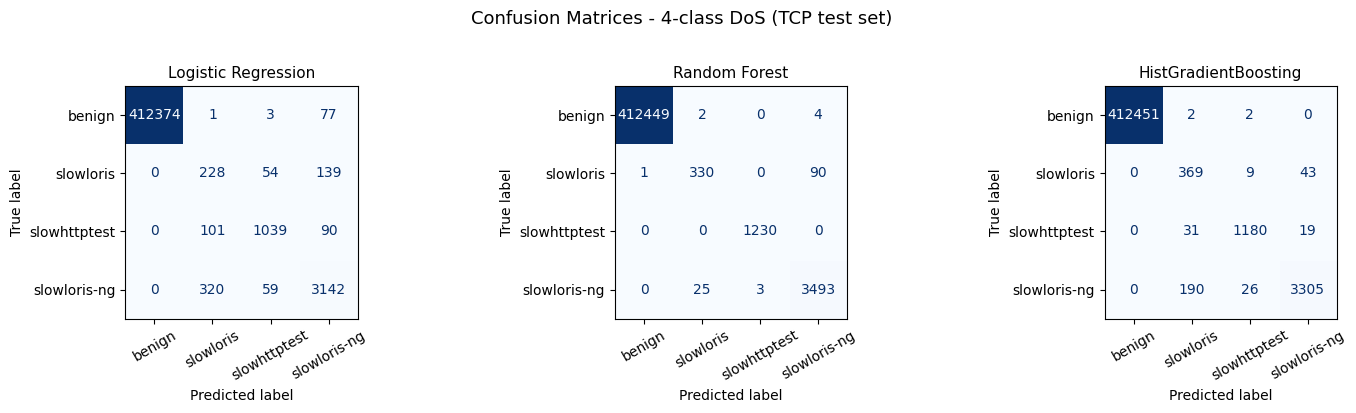

In [29]:
# Confusion matrix grid
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))
if len(results) == 1:
    axes = [axes]

for ax, (name, r) in zip(axes, results.items()):
    disp = ConfusionMatrixDisplay(r['cm'], display_labels=CLASSES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=30)
    ax.set_title(name, fontsize=11)

fig.suptitle('Confusion Matrices - 4-class DoS (TCP test set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
